In [1]:
import sys 
sys.path.append('src')
from sr_model import *

import os
from datasets import load_from_disk, concatenate_datasets
from datasets import Dataset
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader 

In [2]:
data_path = '../sr_project/eval_data/merge_dataset/mdata.h5mu'
import muon as mu 
mdata = mu.read_h5mu(data_path)

train_idx = np.load('../sr_project/eval_data/data_split/train_id_2.npy')
test_idx = np.load('../sr_project/eval_data/data_split/test_id_2.npy')
print(len(train_idx), len(test_idx))

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


60895 6767


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
train_obs = mdata['rna_count'].obs.index[train_idx]
test_obs = mdata['rna_count'].obs.index[test_idx]
print(len(train_obs),len(test_obs), mdata.shape)

60895 6767 (78886, 696445)


## 10x multi 数据预处理

In [4]:
idx = mdata.obs.loc[:,'rna_count:tissues'] != '10x_multi'
rna = mdata['rna_count']
rna = rna[idx,:]
atac = mdata['peak_count']
atac = atac[idx,:]

mdata = MuData({'rna_count': rna, 'peak_count': atac})

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [5]:
import scanpy as sc 
print(rna.shape)
sc.pp.filter_genes(rna, min_cells = int(rna.shape[0] * 0.01))
print(rna.shape) 

sc.pp.normalize_total(rna, target_sum = 1e4)
sc.pp.log1p(rna) 


print(atac.shape)
sc.pp.filter_genes(atac, min_cells = int(atac.shape[0] * 0.01))
print(atac.shape)

sc.pp.normalize_total(atac, target_sum =1e4 )
sc.pp.log1p(atac)

(67662, 32285)


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


(67662, 14108)
(67662, 608869)


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:284: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


(67662, 143989)


In [6]:
# train_rna = rna[train_idx,:]
# test_rna = rna[test_idx,:]

# train_atac = atac[train_idx,:]
# test_atac = atac[test_idx,:]

# train_mdata = MuData({'rna': train_rna, 'atac': train_atac})
# test_mdata = MuData({'rna': test_rna, 'atac': test_atac})

## 设置pair_sr模型

In [7]:
train_pos = mdata['rna_count'].obs.index.get_indexer(train_obs)
test_pos = mdata['rna_count'].obs.index.get_indexer(test_obs)

print(len(train_obs),len(test_obs))

60895 6767


In [8]:
feature_num_1 = rna.shape[1]
feature_num_2 = atac.shape[1]


hidden_params_1 = [1024,512,256]
hidden_params_2 = [1024,512,256]
embed_dim = 128
use_rmsnorm = True
use_residual = True 
dropout_p = 0
clip_temperature = 0.07


pair_model = pair_sr_scratch(feature_num_1, feature_num_2, hidden_params_1, hidden_params_2, embed_dim, use_rmsnorm, use_residual, dropout_p, clip_temperature)
pair_model.create_dataset(mdata, 'rna_count', 'peak_count', train_idx = train_pos, test_idx = test_pos)
pair_model.set_dataloader(batch_size = 512)

In [9]:
# pair_model.create_dataset(mdata, 'rna_count', 'peak_count', train_idx = train_pos, test_idx = test_pos)
# pair_model.set_dataloader(batch_size = 512)
pair_model.set_loss(vae_beta_1= 1.0, vae_beta_2 = 1.0, clip_weight =  40, cross_recon_1 = 0.4,cross_recon_2 = 0.4,temperature = 0.07)


In [10]:
# feature_num_1 = rna.shape[1]
# feature_num_2 = atac.shape[1]


# hidden_params_1 = [1024,256]
# hidden_params_2 = [1024,256]
# embed_dim = 256
# use_rmsnorm = True
# use_residual = True 
# dropout_p = 0
# clip_temperature = 0.07


# pair_model = pair_sr_scratch(feature_num_1, feature_num_2, hidden_params_1, hidden_params_2, embed_dim, use_rmsnorm, use_residual, dropout_p, clip_temperature)



In [11]:
# pair_model.set_loss(vae_beta_1= 1.0, vae_beta_2 = 1.0, clip_weight =  20, cross_recon_1 = 0.4,cross_recon_2 = 0.4,temperature = 0.07)
# pair_model.loss.clip_loss.logit_scale

In [12]:
# pair_model.create_dataset(mdata, 'rna_count', 'peak_count', train_idx = train_pos, test_idx = test_pos)
#pair_model.set_dataloader(batch_size = 512)

In [13]:
# pair_model.set_dataloader(batch_size = 1024)
# pair_model.set_loss(vae_beta_1= 1.0, vae_beta_2 = 1.0, clip_weight =  20, cross_recon_1 = 0.4,cross_recon_2 = 0.4,temperature = 0.07)
#pair_model.loss.to('cuda')
# pair_model.set_optimizer(lr = 1e-3, warmup_steps=400, steady_1_steps = 1600, cosine_anneal_steps=6000, min_lr = 1e-4)
# pair_model.set_project('runs/clip_case_2')
# pair_model.train_model( train_steps = 10000 ,eval_points = 80,save_points = 1000,device = 'cuda')

In [ ]:
import numpy as np 
import pandas as pd 
import json
import scanpy as sc

import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys
import anndata as ad
from tqdm import tqdm

sys.path.append('src')
from metrics import calculate_hit_rate, matching_metrics


record = {}
for key in tqdm(range(1,21)):
    key = int(500*key)    
    print(f'{key} steps' + '==========='*10)
    #key = int(500*key)    
    pair_model.init_model(f'/home/rsun@ZHANGroup.local/solid-recover/runs/clip_case_2_20250919_0422/models/ckpt_{key}.pth')

    model = pair_model.model 
    model.to('cpu')

    model.eval()

    x1 = pair_model.test_dataset.omic_1.to('cpu')
    x2 = pair_model.test_dataset.omic_2.to('cpu')

    z, z_mu, z_logvar, z_embed = model.model_1.get_embedding(x1)
    y,y_mu, y_logvar, y_embed  = model.model_2.get_embedding(x2)

    N = z_embed.shape[0]

    z_mu = z_mu.detach().cpu().numpy()
    z_embed = z_embed.detach().cpu().numpy()

    y_mu = y_mu.detach().cpu().numpy()
    y_embed = y_embed.detach().cpu().numpy()

    mu = np.concatenate([z_mu, y_mu], axis = 0)
    embed = np.concatenate([z_embed, y_embed], axis = 0)

    ## perform evaluation
    res = {}
    ### calculate top_k hit rate
    tmp = []
    for i in [1,5,10,15,20,30,50,100]:
        res[f'top_{i}_hit'] = calculate_hit_rate(z_mu, y_mu, i, metric = 'cosine')

    ### calculate metric score
    acc, ms, fs = matching_metrics(x=z_mu, y = y_mu, metric='cosine')
    res['acc'] = acc 
    res['mathscore'] = ms 
    res['foscttm'] = fs

    print(res)
    record[key] = res


500 steps==============================================================================================================


/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(13534, 128)
(13534, 128)
{'top_1_hit': 0.009974878084823408, 'top_5_hit': 0.054012117629673416, 'top_10_hit': 0.1011526525786907, 'top_15_hit': 0.14260381262006797, 'top_20_hit': 0.1771095019949756, 'top_30_hit': 0.23437269100044333, 'top_50_hit': 0.3221516181468893, 'top_100_hit': 0.46542042263927885}
{'top_1_hit': 0.009974878084823408, 'top_5_hit': 0.054012117629673416, 'top_10_hit': 0.1011526525786907, 'top_15_hit': 0.14260381262006797, 'top_20_hit': 0.1771095019949756, 'top_30_hit': 0.23437269100044333, 'top_50_hit': 0.3221516181468893, 'top_100_hit': 0.46542042263927885, 'acc': 0.025417467579245567, 'mathscore': 0.025417467579245567, 'foscttm': 0.026702924631536007}
{'top_1_hit': 0.01012265405645042, 'top_5_hit': 0.054677109501994975, 'top_10_hit': 0.10159598049357174, 'top_15_hit': 0.1439337963647111, 'top_20_hit': 0.1781439337963647, 'top_30_hit': 0.23555489877345945, 'top_50_hit': 0.32266883404758384, 'top_100_hit': 0.46534653465346537}
{'top_1_hit': 0.01012265405645042, 'top_

/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(13534, 128)
(13534, 128)
{'top_1_hit': 0.05282990985665731, 'top_5_hit': 0.16610019210876312, 'top_10_hit': 0.2503324959361608, 'top_15_hit': 0.30781734889906903, 'top_20_hit': 0.3485296290823112, 'top_30_hit': 0.41672823998817793, 'top_50_hit': 0.504507167134624, 'top_100_hit': 0.6341805822373282}
{'top_1_hit': 0.05282990985665731, 'top_5_hit': 0.16610019210876312, 'top_10_hit': 0.2503324959361608, 'top_15_hit': 0.30781734889906903, 'top_20_hit': 0.3485296290823112, 'top_30_hit': 0.41672823998817793, 'top_50_hit': 0.504507167134624, 'top_100_hit': 0.6341805822373282, 'acc': 0.04388946294784546, 'mathscore': 0.04507167264819145, 'foscttm': 0.023821892216801643}
{'top_1_hit': 0.05415989360130043, 'top_5_hit': 0.1670607359243387, 'top_10_hit': 0.2507758238510418, 'top_15_hit': 0.3098123245160337, 'top_20_hit': 0.3502290527560219, 'top_30_hit': 0.4175410078321265, 'top_50_hit': 0.5065760307374021, 'top_100_hit': 0.6380227574996306}
{'top_1_hit': 0.05415989360130043, 'top_5_hit': 0.167060

...

(13534, 128)
(13534, 128)
{'top_1_hit': 0.12051130486182947, 'top_5_hit': 0.27538052312693956, 'top_10_hit': 0.36552386581941776, 'top_15_hit': 0.4220481749667504, 'top_20_hit': 0.46445987882370326, 'top_30_hit': 0.521870843800798, 'top_50_hit': 0.5973843653022018, 'top_100_hit': 0.6927737549874391}
{'top_1_hit': 0.12051130486182947, 'top_5_hit': 0.27538052312693956, 'top_10_hit': 0.36552386581941776, 'top_15_hit': 0.4220481749667504, 'top_20_hit': 0.46445987882370326, 'top_30_hit': 0.521870843800798, 'top_50_hit': 0.5973843653022018, 'top_100_hit': 0.6927737549874391, 'acc': 0.09398552030324936, 'mathscore': 0.09383774548768997, 'foscttm': 0.030369347892701626}
{'top_1_hit': 0.12021575291857543, 'top_5_hit': 0.27759716270134477, 'top_10_hit': 0.36626274567755285, 'top_15_hit': 0.42286094281069897, 'top_20_hit': 0.46578986256834637, 'top_30_hit': 0.5234963794886951, 'top_50_hit': 0.5971627013447613, 'top_100_hit': 0.6951381705334713}
{'top_1_hit': 0.12021575291857543, 'top_5_hit': 0.27

/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(13534, 128)
(13534, 128)
{'top_1_hit': 0.12405792818087778, 'top_5_hit': 0.280552682133885, 'top_10_hit': 0.37187823259937935, 'top_15_hit': 0.4252253583567312, 'top_20_hit': 0.46431210285207625, 'top_30_hit': 0.5206886360277819, 'top_50_hit': 0.5911777744938673, 'top_100_hit': 0.6935126348455741}
{'top_1_hit': 0.12405792818087778, 'top_5_hit': 0.280552682133885, 'top_10_hit': 0.37187823259937935, 'top_15_hit': 0.4252253583567312, 'top_20_hit': 0.46431210285207625, 'top_30_hit': 0.5206886360277819, 'top_50_hit': 0.5911777744938673, 'top_100_hit': 0.6935126348455741, 'acc': 0.09878823161125183, 'mathscore': 0.1001921072602272, 'foscttm': 0.030596548691391945}
{'top_1_hit': 0.12391015220925078, 'top_5_hit': 0.2810698980345796, 'top_10_hit': 0.3716565686419388, 'top_15_hit': 0.42707255800206884, 'top_20_hit': 0.4666765183981085, 'top_30_hit': 0.521723067829171, 'top_50_hit': 0.5931727501108319, 'top_100_hit': 0.6941776267178956}
{'top_1_hit': 0.12391015220925078, 'top_5_hit': 0.281069898

/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(13534, 128)
(13534, 128)
{'top_1_hit': 0.11777744938672972, 'top_5_hit': 0.2773754987439042, 'top_10_hit': 0.36892271316683906, 'top_15_hit': 0.4248559184276637, 'top_20_hit': 0.46630707846904096, 'top_30_hit': 0.5195064282547658, 'top_50_hit': 0.5913994384513078, 'top_100_hit': 0.6888576917393232}
{'top_1_hit': 0.11777744938672972, 'top_5_hit': 0.2773754987439042, 'top_10_hit': 0.36892271316683906, 'top_15_hit': 0.4248559184276637, 'top_20_hit': 0.46630707846904096, 'top_30_hit': 0.5195064282547658, 'top_50_hit': 0.5913994384513078, 'top_100_hit': 0.6888576917393232, 'acc': 0.09849268198013306, 'mathscore': 0.10314762592315674, 'foscttm': 0.029399840161204338}
{'top_1_hit': 0.11829466528742426, 'top_5_hit': 0.27863159450273384, 'top_10_hit': 0.3705482488547362, 'top_15_hit': 0.42722033397369585, 'top_20_hit': 0.46785872617112456, 'top_30_hit': 0.5206886360277819, 'top_50_hit': 0.5916949903945619, 'top_100_hit': 0.6915176592286094}
{'top_1_hit': 0.11829466528742426, 'top_5_hit': 0.278

In [ ]:
## 0.092

## 0.052 
## 0.0776
## 0.0790
## 0.0890
## 0.0964
## 0.1032  ###目标值0.1044
## 0.1152

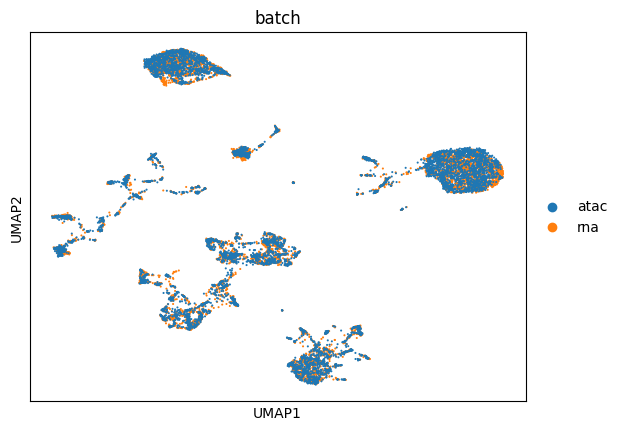

In [16]:
adata = ad.AnnData(X = np.random.rand(2*N,10))
adata.obs.loc[:,'batch'] = ['rna']*N + ['atac']*N
adata.obsm['mu'] = mu 
adata.obsm['embed'] = mu 

sc.pp.neighbors(adata, use_rep='mu')
sc.tl.umap(adata, min_dist = 0.1)
sc.pl.umap(adata, color='batch')



In [30]:
matching_metrics(x=z_embed, y = y_embed, metric='euclidean')

(0.09849268198013306, 0.10314762592315674, 0.029399840161204338)

In [ ]:
sc.pp.neighbors(adata, use_rep='embed')
sc.tl.umap(adata, min_dist = 0.1)
sc.pl.umap(adata, color='batch')


In [19]:
import torch
import scipy
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist

x = z_mu
y = y_mu
distance = cdist(x, y, metric="euclidean")
similarity = -distance  # Negative distance as similarity
print(similarity.shape)

(6767, 6767)


In [25]:
torch.sum(torch.argmax(similarity, dim=1) == torch.arange(batch_size)) / batch_size

tensor(0.2239)

In [27]:
acc = (acc_x + acc_y) / 2
print(acc)

tensor(0.2176)


In [ ]:
acc_y = (
    torch.sum(
        torch.argmax(similarity, dim=0)
        == torch.arange(batch_size).to(similarity.device)
    )
    / batch_size
)

tensor([   0,    1,    2,  ..., 6764, 6765, 6766])

In [20]:
if not isinstance(similarity, torch.Tensor):
    similarity = torch.from_numpy(similarity)

with torch.no_grad():
    # similarity = output.logits_per_atac
    batch_size = similarity.shape[0]
    acc_x = (
        torch.sum(
            torch.argmax(similarity, dim=1)
            == torch.arange(batch_size).to(similarity.device)
        )
        / batch_size
    )
    acc_y = (
        torch.sum(
            torch.argmax(similarity, dim=0)
            == torch.arange(batch_size).to(similarity.device)
        )
        / batch_size
    )

In [ ]:
import torch
import scipy
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist

x = z_mu
y = y_mu
distance = cdist(x, y, metric="euclidean")
similarity = -distance  # Negative distance as similarity

def matching_metrics(similarity=None, x=None, y=None, metric = 'euclidean', **kwargs):

    if similarity is None:
        if x.shape != y.shape:
            raise ValueError("Shapes of x and y do not match!")
        
        if metric == "cosine":
            # Compute cosine similarity
            x_norm = np.linalg.norm(x, axis=1, keepdims=True)
            y_norm = np.linalg.norm(y, axis=1, keepdims=True)
            similarity = np.dot(x, y.T) / (x_norm * y_norm.T + 1e-8)  # Add epsilon to avoid division by zero
        
        elif metric == "euclidean":
            # Compute Euclidean distance and convert to similarity
            distance = cdist(x, y, metric="euclidean", **kwargs)
            similarity = -distance  # Negative distance as similarity
        
        else:
            raise ValueError("Unsupported metric. Choose 'cosine' or 'euclidean'.")

    if not isinstance(similarity, torch.Tensor):
        similarity = torch.from_numpy(similarity)

    with torch.no_grad():
        # similarity = output.logits_per_atac
        batch_size = similarity.shape[0]
        acc_x = (
            torch.sum(
                torch.argmax(similarity, dim=1)
                == torch.arange(batch_size).to(similarity.device)
            )
            / batch_size
        )
        acc_y = (
            torch.sum(
                torch.argmax(similarity, dim=0)
                == torch.arange(batch_size).to(similarity.device)
            )
            / batch_size
        )
        foscttm_x = (
            (similarity > torch.diag(similarity)).float().mean(axis=1).mean().item()
        )
        foscttm_y = (
            (similarity > torch.diag(similarity)).float().mean(axis=0).mean().item()
        )
        # matchscore_x = similarity.softmax(dim=1).diag().mean().item()
        # matchscore_y = similarity.softmax(dim=0).diag().mean().item()
        X = similarity
        mx = torch.max(X, dim=1, keepdim=True).values
        hard_X = (mx == X).float()
        logits_row_sums = hard_X.clip(min=0).sum(dim=1)
        matchscore = hard_X.clip(min=0).diagonal().div(logits_row_sums).mean().item()

        acc = (acc_x + acc_y) / 2
        foscttm = (foscttm_x + foscttm_y) / 2
        # matchscore = (matchscore_x + matchscore_y)/2
        return acc.item(), matchscore, foscttm


In [32]:
embeddings_a = z_mu 
embeddings_b = y_mu
metric = 'euclidean'
K = 1

N = embeddings_a.shape[0]
if embeddings_b.shape[0] != N:
    raise ValueError("两个模态的样本数量必须一致")

count = 0

# 将两个模态的embedding合并成一个大的embedding集合
all_embeddings = np.vstack([embeddings_a, embeddings_b])  # 形状 (2N, d)

# 方向1: 模态A到模态B的匹配
nbrs_a = NearestNeighbors(n_neighbors=K + 1, metric=metric, algorithm='auto').fit(all_embeddings)  # K+1 是为了排除自身
_, indices_a = nbrs_a.kneighbors(embeddings_a)
# for i in range(N):
#     # 排除自身后检查是否命中对应的模态B的embedding
#     neighbors = indices_a[i][1:]  # 排除第一个邻居（自身）
#     if (i + N) in neighbors:  # 模态B的第i个embedding在模态A的K近邻中
#         count += 1

In [33]:
indices_a

array([[    0,  8883],
       [    1,  9151],
       [    2, 12296],
       ...,
       [ 6764,  3597],
       [ 6765,  1947],
       [ 6766, 12747]])

In [35]:
key = 12
key = int(500*key)    
print(f'{key} steps' + '==========='*10)
#key = int(500*key)    
pair_model.init_model(f'/home/rsun@ZHANGroup.local/solid-recover/runs/clip_case_2_20250919_0422/models/ckpt_{key}.pth')

model = pair_model.model 
model.to('cpu')

model.eval()

x1 = pair_model.test_dataset.omic_1.to('cpu')
x2 = pair_model.test_dataset.omic_2.to('cpu')

z, z_mu, z_logvar, z_embed = model.model_1.get_embedding(x1)
y,y_mu, y_logvar, y_embed  = model.model_2.get_embedding(x2)

import anndata as ad 

N = z_embed.shape[0]

z_mu = z_mu.detach().cpu().numpy()
z_embed = z_embed.detach().cpu().numpy()

y_mu = y_mu.detach().cpu().numpy()
y_embed = y_embed.detach().cpu().numpy()

mu = np.concatenate([z_mu, y_mu], axis = 0)
print(mu.shape)
embed = np.concatenate([z_embed, y_embed], axis = 0)
print(embed.shape)

import numpy as np 
import pandas as pd 
import json
import scanpy as sc

import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys
import anndata as ad

sys.path.append('/home/rsun@ZHANGroup.local/sr_project/src')
from metrics import calculate_hit_rate, matching_metrics


## perform evaluation
res = {}
### calculate top_k hit rate
tmp = []
for i in [1,5,10,15,20,30,50,100]:
    res[f'top_{i}_hit'] = calculate_hit_rate(z_mu, y_mu, i, metric = 'euclidean')
print(res)

### calculate metric score
acc, ms, fs = matching_metrics(x=z_mu, y = y_mu, metric='euclidean')
res['acc'] = acc 
res['mathscore'] = ms 
res['foscttm'] = fs

print(res)


## perform evaluation
res = {}
### calculate top_k hit rate
tmp = []
for i in [1,5,10,15,20,30,50,100]:
    res[f'top_{i}_hit'] = calculate_hit_rate(z_mu, y_mu, i, metric = 'cosine')
print(res)

### calculate metric score
acc, ms, fs = matching_metrics(x=z_mu, y = y_mu, metric='cosine')
res['acc'] = acc 
res['mathscore'] = ms 
res['foscttm'] = fs

print(res)



6000 steps==============================================================================================================


/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(13534, 128)
(13534, 128)
{'top_1_hit': 0.11777744938672972, 'top_5_hit': 0.2773754987439042, 'top_10_hit': 0.36892271316683906, 'top_15_hit': 0.4248559184276637, 'top_20_hit': 0.46630707846904096, 'top_30_hit': 0.5195064282547658, 'top_50_hit': 0.5913994384513078, 'top_100_hit': 0.6888576917393232}
{'top_1_hit': 0.11777744938672972, 'top_5_hit': 0.2773754987439042, 'top_10_hit': 0.36892271316683906, 'top_15_hit': 0.4248559184276637, 'top_20_hit': 0.46630707846904096, 'top_30_hit': 0.5195064282547658, 'top_50_hit': 0.5913994384513078, 'top_100_hit': 0.6888576917393232, 'acc': 0.21760012209415436, 'mathscore': 0.2238806039094925, 'foscttm': 0.015642174519598484}
{'top_1_hit': 0.11829466528742426, 'top_5_hit': 0.27863159450273384, 'top_10_hit': 0.3705482488547362, 'top_15_hit': 0.42722033397369585, 'top_20_hit': 0.46785872617112456, 'top_30_hit': 0.5206886360277819, 'top_50_hit': 0.5916949903945619, 'top_100_hit': 0.6915176592286094}
{'top_1_hit': 0.11829466528742426, 'top_5_hit': 0.2786

In [36]:


model = pair_model.model 
model.to('cpu')

model.eval()

x1 = pair_model.test_dataset.omic_1.to('cpu')
x2 = pair_model.test_dataset.omic_2.to('cpu')

z, z_mu, z_logvar, z_embed = model.model_1.get_embedding(x1)
y,y_mu, y_logvar, y_embed  = model.model_2.get_embedding(x2)

import anndata as ad 

N = z_embed.shape[0]

z_mu = z_mu.detach().cpu().numpy()
z_embed = z_embed.detach().cpu().numpy()

y_mu = y_mu.detach().cpu().numpy()
y_embed = y_embed.detach().cpu().numpy()

mu = np.concatenate([z_mu, y_mu], axis = 0)
print(mu.shape)
embed = np.concatenate([z_embed, y_embed], axis = 0)
print(embed.shape)

import numpy as np 
import pandas as pd 
import json
import scanpy as sc

import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys
import anndata as ad

sys.path.append('/home/rsun@ZHANGroup.local/sr_project/src')
from metrics import calculate_hit_rate, matching_metrics


## perform evaluation
res = {}
### calculate top_k hit rate
tmp = []
for i in [1,5,10,15,20,30,50,100]:
    res[f'top_{i}_hit'] = calculate_hit_rate(z_embed, y_embed, i, metric = 'euclidean')
print(res)

### calculate metric score
acc, ms, fs = matching_metrics(x=z_embed, y = y_embed, metric='euclidean')
res['acc'] = acc 
res['mathscore'] = ms 
res['foscttm'] = fs

print(res)


## perform evaluation
res = {}
### calculate top_k hit rate
tmp = []
for i in [1,5,10,15,20,30,50,100]:
    res[f'top_{i}_hit'] = calculate_hit_rate(z_embed, y_embed, i, metric = 'cosine')
print(res)

### calculate metric score
acc, ms, fs = matching_metrics(x=z_embed, y = y_embed, metric='cosine')
res['acc'] = acc 
res['mathscore'] = ms 
res['foscttm'] = fs

print(res)



(13534, 128)
(13534, 128)
{'top_1_hit': 0.05334712575735186, 'top_5_hit': 0.1604108172011231, 'top_10_hit': 0.23984040195064282, 'top_15_hit': 0.2948130633958918, 'top_20_hit': 0.33818531106842026, 'top_30_hit': 0.4045367223289493, 'top_50_hit': 0.4957144968228166, 'top_100_hit': 0.6100192108763115}
{'top_1_hit': 0.05334712575735186, 'top_5_hit': 0.1604108172011231, 'top_10_hit': 0.23984040195064282, 'top_15_hit': 0.2948130633958918, 'top_20_hit': 0.33818531106842026, 'top_30_hit': 0.4045367223289493, 'top_50_hit': 0.4957144968228166, 'top_100_hit': 0.6100192108763115, 'acc': 0.10011821985244751, 'mathscore': 0.10492093861103058, 'foscttm': 0.03154751472175121}
{'top_1_hit': 0.05903650066499187, 'top_5_hit': 0.17393231860499483, 'top_10_hit': 0.26082458992167873, 'top_15_hit': 0.31572336338111423, 'top_20_hit': 0.3616816905571154, 'top_30_hit': 0.4314319491650658, 'top_50_hit': 0.5142603812620068, 'top_100_hit': 0.6290084232303828}
{'top_1_hit': 0.05903650066499187, 'top_5_hit': 0.1739